In [2]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import factorial
import scienceplots

plt.style.use(['science','notebook', 'grid'])

In [31]:
L = 20
N = 1000
xc = 3
alpha = 15
x = np.linspace(-L/2, L/2, N)

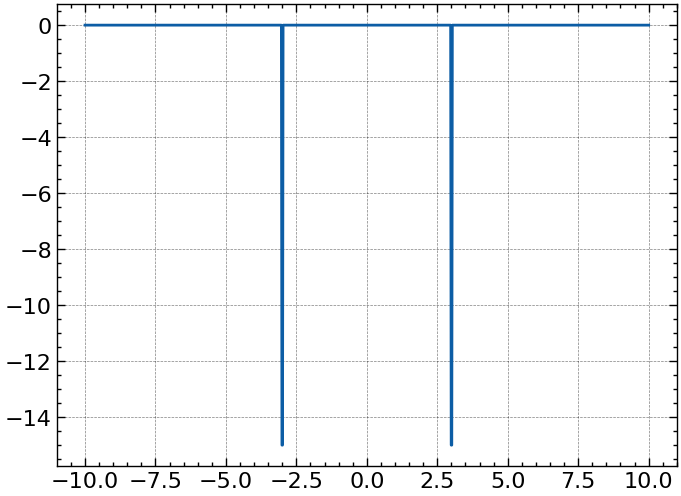

In [32]:
def Potential(x, a=xc, alpha=alpha, epsilon=L/N):
    potential = np.zeros(len(x))
    for i in range(len(x)):
        if(x[i] < -a - epsilon):
            potential[i] = 0
        elif(x[i] < -a + epsilon):
            potential[i] = -alpha
        elif(x[i] < a - epsilon):
            potential[i] = 0
        elif(x[i] < a + epsilon):
            potential[i] = -alpha
        else:
            potential[i] = 0
    return potential

plt.plot(x,Potential(x))

In [33]:
dx = np.diff(x)[0]

main_diag = 2*np.ones(N)/dx**2 + Potential(x)
main_diag[0] -= 1/dx**2 
main_diag[-1] -= 1/dx**2 
off_diag = -np.ones(N-1)/dx**2

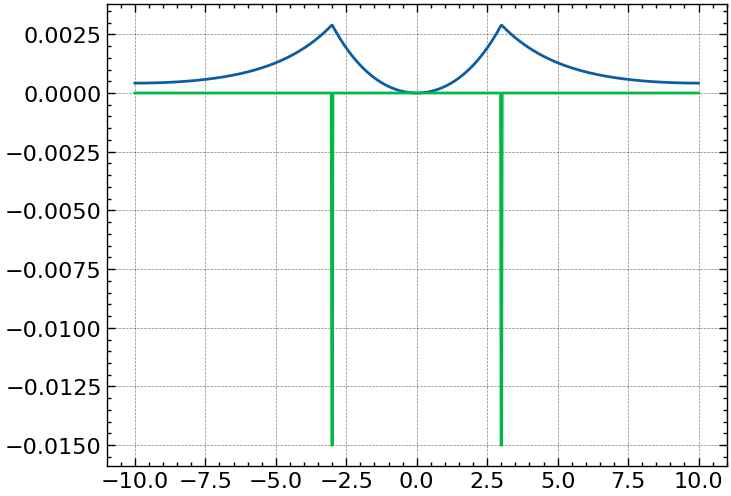

In [40]:
from scipy.linalg import eigh_tridiagonal

En, psis = eigh_tridiagonal(main_diag, off_diag, False, select = 'v', select_range = (-100, 0))

plt.plot(x, np.abs(psis.T[1])**2)
plt.plot(x,Potential(x)/1000)